# Protrusion length per sickle cell — paper Figure 2e

This notebook produces the paper's **Figure 2e** metric: the *average HbS
protrusion length per sickle cell, pooled per condition*.

For each condition, all its fields of view (FOVs) are pooled and the
metric is formed as a single ratio:

> `um_per_sickle = sum(protrusion_length_um across FOVs) / sum(n_sickle across FOVs)`

reported as one number per condition with a 1000-resample bootstrap 95%
CI over FOV resampling. Because the metric is a pool ratio (not a mean of
per-FOV ratios), no per-FOV minimum-sickle filter is needed; the only
FOV filter is a crowding upper bound (`n_cells <= MAX_CELLS`) that drops
biologically suspect over-dense fields.

The paper's numbers (HbAA 8.1 um, HbSS 25.3 um, LNP 22.2-22.7 um,
EP 15.3-19.1 um) come straight out of the figure cell below.

## Input

`sickling/rbc_classification/experiment_data/per_fov_dist10.parquet` -
per-FOV protrusion length + sickle / cell counts, filtered with the
biologically-motivated `MAX_DIST_FROM_CELL_PX = 10` (protrusion blobs
farther than 10 px from any segmented cell are treated as segmentation
noise). This parquet is committed to the repo, so the notebook runs
self-contained.

## Outputs

- `notebooks/figures/sickle_polymer_per_condition_pool_dist10.svg` / `.png`
- `notebooks/figures/sickle_polymer_per_condition_pool_dist10.csv`


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Make the sickling package importable when running from the notebook dir.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['pdf.fonttype'] = 42
print('REPO_ROOT =', REPO_ROOT)


REPO_ROOT = E:\utku g leica\sickling-publish


In [2]:
# --- inputs (edit me) ----------------------------------------------------
EXPERIMENT_DATA = REPO_ROOT / 'sickling' / 'rbc_classification' / 'experiment_data'
PER_FOV_PARQUET = EXPERIMENT_DATA / 'per_fov_dist10.parquet'
FIGURES_DIR     = REPO_ROOT / 'notebooks' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Condition grouping. The three HbA controls are pooled into one
# 'neg_control' sample (per the study design); every other condition
# stands alone. CONDITION_ORDER sets the left-to-right column order.
NEGATIVE_CONTROL_CONDITIONS = ['ALHi', 'ALLo', 'A-UNT']
POSITIVE_CONTROL_CONDITIONS = ['S-UNT']
TREATMENT_CONDITIONS        = ['SLN1', 'SLHi', 'SE1', 'SE2']

def _group(cond):
    return 'neg_control' if cond in NEGATIVE_CONTROL_CONDITIONS else cond

CONDITION_ORDER = ['neg_control'] + POSITIVE_CONTROL_CONDITIONS + TREATMENT_CONDITIONS

# Crowding filter: drop over-dense FOVs (biologically suspect). No per-FOV
# minimum-sickle filter is applied - the pool ratio doesn't need one.
MAX_CELLS = 500

# Figure style (paper palette).
VIOLIN_BORDER     = '#c1440eff'   # protrusion-burden dot + CI bar
SICKLE_FRAC_COLOR = '#1719e7ff'   # sickle-fraction diamond
SICKLE_FRAC_YLIM  = (-0.007, 0.115)

fov_df = pd.read_parquet(PER_FOV_PARQUET)
fov_df['group'] = fov_df['condition'].map(_group)
print(f'per-FOV records : {len(fov_df)}')
print(f'conditions      : {sorted(fov_df["condition"].unique())}')
print(f'groups          : {[g for g in CONDITION_ORDER if g in fov_df["group"].unique()]}')


per-FOV records : 3008
conditions      : ['A-UNT', 'ALHi', 'ALLo', 'S-UNT', 'SE1', 'SE2', 'SLHi', 'SLN1']
groups          : ['neg_control', 'S-UNT', 'SLN1', 'SLHi', 'SE1', 'SE2']


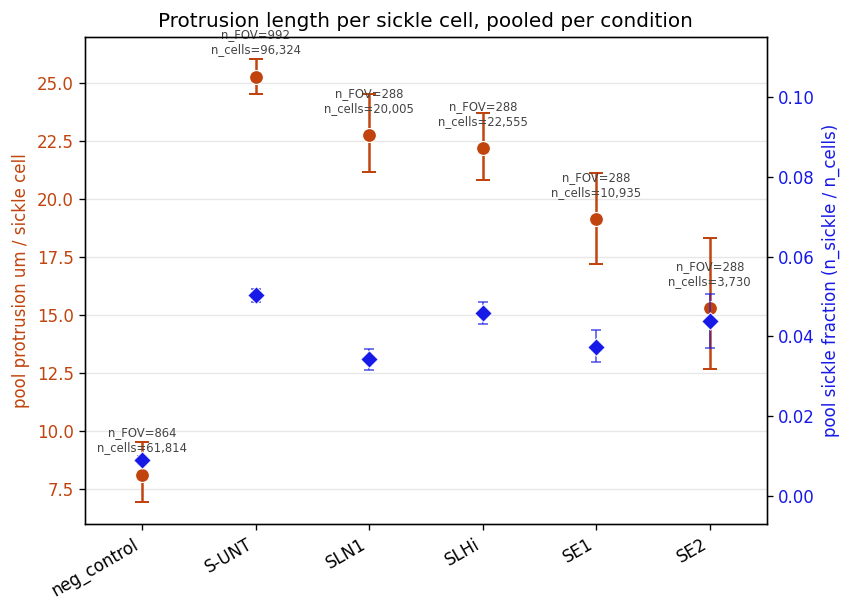

POOL stats per condition  (MAX_CELLS <= 500, no MIN_SICKLE):
  group        n_FOVs   n_cells  n_sickle  sickle_%   um/sickle            95% CI
  neg_control     864    61,814       554     0.90%       8.12      [6.95, 9.51]
  S-UNT           992    96,324     4,845     5.03%      25.27    [24.52, 26.02]
  SLN1            288    20,005       687     3.43%      22.75    [21.15, 24.54]
  SLHi            288    22,555     1,037     4.60%      22.18    [20.81, 23.70]
  SE1             288    10,935       409     3.74%      19.12    [17.19, 21.12]
  SE2             288     3,730       164     4.40%      15.28    [12.66, 18.31]

wrote: E:\utku g leica\sickling-publish\notebooks\figures\sickle_polymer_per_condition_pool_dist10.svg
wrote: E:\utku g leica\sickling-publish\notebooks\figures\sickle_polymer_per_condition_pool_dist10.png
wrote: E:\utku g leica\sickling-publish\notebooks\figures\sickle_polymer_per_condition_pool_dist10.csv


In [3]:
# === Paper Figure 2e: pool-level protrusion length per sickle cell =======
# For each condition, pool n_sickle, n_cells and protrusion_length_um
# across all FOVs (after the crowding filter), then report:
#     um_per_sickle = sum(protrusion_length_um) / sum(n_sickle)
#     sickle_frac   = sum(n_sickle) / sum(n_cells)
# Bootstrap 95% CIs come from resampling FOVs with replacement within each
# group (N_BOOT iterations, fixed seed for reproducibility). The point
# estimates are exact pool ratios; only the CI bars are stochastic.
N_BOOT = 1000
RNG    = np.random.default_rng(0)


def _pool_stats(df_in, group_col='group'):
    df = df_in[df_in['n_cells'] <= MAX_CELLS].copy()
    groups = [g for g in CONDITION_ORDER if g in df[group_col].unique()]
    rows = []
    for g in groups:
        sub = df[df[group_col] == g]
        n_cells_total  = int(sub['n_cells'].sum())
        n_sickle_total = int(sub['n_sickle'].sum())
        polymer_total  = float(sub['polymer_length_um'].sum())
        sickle_frac   = n_sickle_total / n_cells_total if n_cells_total else float('nan')
        um_per_sickle = polymer_total / n_sickle_total if n_sickle_total else float('nan')

        idx = np.arange(len(sub))
        ns = sub['n_sickle'].to_numpy()
        nc = sub['n_cells'].to_numpy()
        pl = sub['polymer_length_um'].to_numpy()
        sf_boot = np.empty(N_BOOT)
        us_boot = np.empty(N_BOOT)
        for b in range(N_BOOT):
            samp = RNG.choice(idx, size=len(idx), replace=True)
            nc_s = nc[samp].sum(); ns_s = ns[samp].sum(); pl_s = pl[samp].sum()
            sf_boot[b] = ns_s / nc_s if nc_s else np.nan
            us_boot[b] = pl_s / ns_s if ns_s else np.nan

        rows.append({
            'group': g, 'n_FOVs': int(len(sub)),
            'n_cells_total': n_cells_total, 'n_sickle_total': n_sickle_total,
            'polymer_total_um': polymer_total,
            'sickle_frac': sickle_frac,
            'sickle_frac_lo': float(np.nanpercentile(sf_boot, 2.5)),
            'sickle_frac_hi': float(np.nanpercentile(sf_boot, 97.5)),
            'um_per_sickle': um_per_sickle,
            'um_per_sickle_lo': float(np.nanpercentile(us_boot, 2.5)),
            'um_per_sickle_hi': float(np.nanpercentile(us_boot, 97.5)),
        })
    return pd.DataFrame(rows)


def _draw_pool(ax, stats):
    xs = np.arange(1, len(stats) + 1)

    # Left axis: pooled protrusion um / sickle cell, with bootstrap CI bar.
    ax.errorbar(xs, stats['um_per_sickle'],
                yerr=[stats['um_per_sickle'] - stats['um_per_sickle_lo'],
                      stats['um_per_sickle_hi'] - stats['um_per_sickle']],
                fmt='none', ecolor=VIOLIN_BORDER, elinewidth=1.5,
                capsize=4, capthick=1.2, zorder=3)
    ax.scatter(xs, stats['um_per_sickle'], color=VIOLIN_BORDER, s=70,
               edgecolors='white', linewidths=0.7, zorder=4)
    ax.set_xticks(xs); ax.set_xticklabels(stats['group'], rotation=30, ha='right')
    ax.set_xlim(0.5, len(stats) + 0.5)
    ax.set_ylabel('pool protrusion um / sickle cell', color=VIOLIN_BORDER)
    ax.tick_params(axis='y', labelcolor=VIOLIN_BORDER)
    ax.grid(alpha=0.3, axis='y')
    ax.set_title('Protrusion length per sickle cell, pooled per condition')

    # Right axis: pooled sickle fraction.
    ax2 = ax.twinx()
    ax2.errorbar(xs, stats['sickle_frac'],
                 yerr=[stats['sickle_frac'] - stats['sickle_frac_lo'],
                       stats['sickle_frac_hi'] - stats['sickle_frac']],
                 fmt='none', ecolor=SICKLE_FRAC_COLOR, elinewidth=1.0,
                 capsize=3, capthick=1.0, zorder=3, alpha=0.7)
    ax2.scatter(xs, stats['sickle_frac'], color=SICKLE_FRAC_COLOR, s=55,
                marker='D', edgecolors='white', linewidths=0.6, zorder=4)
    ax2.set_ylim(*SICKLE_FRAC_YLIM)
    ax2.set_ylabel('pool sickle fraction (n_sickle / n_cells)', color=SICKLE_FRAC_COLOR)
    ax2.tick_params(axis='y', labelcolor=SICKLE_FRAC_COLOR)

    for i, row in stats.iterrows():
        ax.annotate(f'n_FOV={row["n_FOVs"]}\nn_cells={row["n_cells_total"]:,}',
                    (i + 1, row['um_per_sickle']),
                    textcoords='offset points', xytext=(0, 14),
                    fontsize=7, ha='center', color='#444')


stats = _pool_stats(fov_df)

fig_w = max(5.5, 1.2 * len(stats))
fig, ax = plt.subplots(figsize=(fig_w, 5.2), dpi=120)
_draw_pool(ax, stats)
fig.tight_layout()
out_svg = FIGURES_DIR / 'sickle_polymer_per_condition_pool_dist10.svg'
out_png = FIGURES_DIR / 'sickle_polymer_per_condition_pool_dist10.png'
fig.savefig(out_svg, bbox_inches='tight')
fig.savefig(out_png, dpi=200, bbox_inches='tight')
plt.show()

# --- headline table ---
show = stats[['group', 'n_FOVs', 'n_cells_total', 'n_sickle_total',
              'sickle_frac', 'um_per_sickle',
              'um_per_sickle_lo', 'um_per_sickle_hi']].copy()
show['sickle_pct'] = (show['sickle_frac'] * 100).round(2)
print(f'POOL stats per condition  (MAX_CELLS <= {MAX_CELLS}, no MIN_SICKLE):')
print(f'  {"group":11s} {"n_FOVs":>7s} {"n_cells":>9s} {"n_sickle":>9s} '
      f'{"sickle_%":>9s} {"um/sickle":>11s}  {"95% CI":>16s}')
for _, r in show.iterrows():
    ci = f'[{r["um_per_sickle_lo"]:.2f}, {r["um_per_sickle_hi"]:.2f}]'
    print(f'  {r["group"]:11s} {int(r["n_FOVs"]):>7d} '
          f'{int(r["n_cells_total"]):>9,d} {int(r["n_sickle_total"]):>9,d} '
          f'{r["sickle_pct"]:>8.2f}% {r["um_per_sickle"]:>10.2f}  {ci:>16s}')

out_csv = FIGURES_DIR / 'sickle_polymer_per_condition_pool_dist10.csv'
stats.to_csv(out_csv, index=False)
print()
print(f'wrote: {out_svg}')
print(f'wrote: {out_png}')
print(f'wrote: {out_csv}')
